🚨 탐방(절반 수강) 없이 수료증을 따낸 예외(Anomaly) 인원수: 690명

👇 [탐방 스킵 수료자] 코스별 인원 분포표 👇


course_id
HarvardX/ER22x/2013_Spring     454
HarvardX/PH278x/2013_Spring     72
MITx/3.091x/2013_Spring         31
MITx/8.MReV/2013_Summer         30
MITx/6.00x/2012_Fall            26
MITx/7.00x/2013_Spring          21
MITx/6.002x/2013_Spring         20
MITx/6.002x/2012_Fall           16
MITx/14.73x/2013_Spring          9
HarvardX/CS50x/2012              5
HarvardX/CB22x/2013_Spring       2
HarvardX/PH207x/2012_Fall        1
MITx/8.02x/2013_Spring           1
MITx/2.01x/2013_Spring           1
MITx/6.00x/2013_Spring           1
Name: count, dtype: int64

C:\Users\gorhk\AppData\Local\Temp\ipykernel_251764\498113307.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


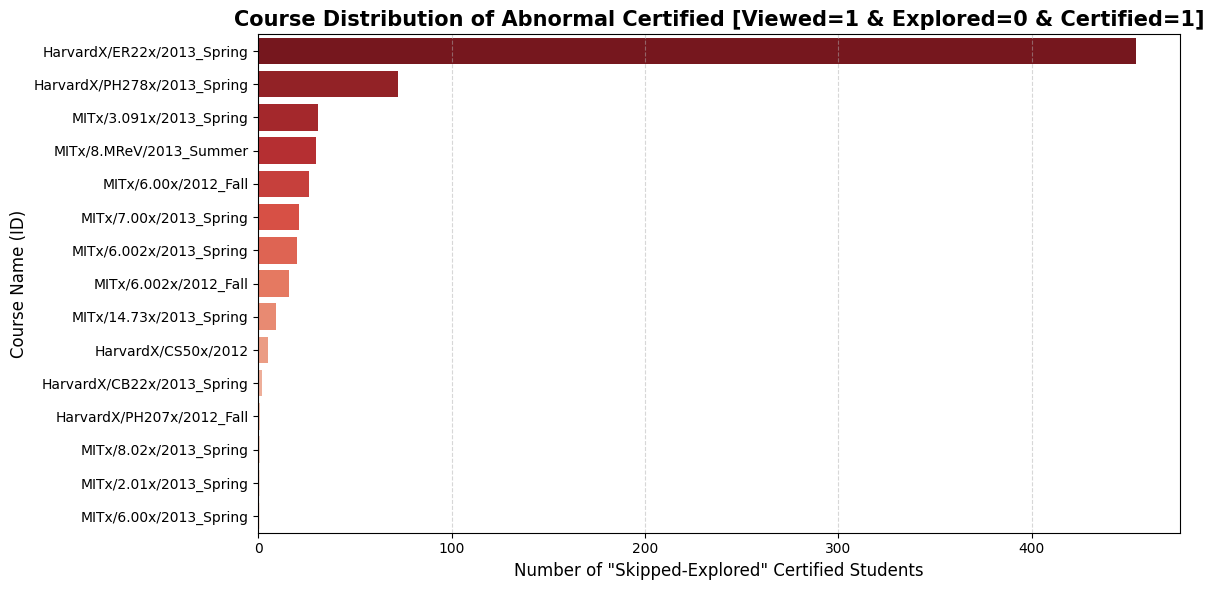

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 원본 파일 새로 읽어오기 (경로에 한글 띄어쓰기가 있어 r 문자열 사용)
df_raw = pd.read_csv('Courses.csv')

# 2. 조건 필터링: 조회(O) -> 탐방(X) -> 수료(O) 인 미스터리한 인원들 추출
anomaly_cert_df = df_raw[(df_raw['viewed'] == 1) & (df_raw['explored'] == 0) & (df_raw['certified'] == 1)]

print(f"🚨 탐방(절반 수강) 없이 수료증을 따낸 예외(Anomaly) 인원수: {len(anomaly_cert_df):,}명\n")

# 3. 이 인원들이 어떤 강좌에서 배출되었는지 코스별 분포 확인
course_distribution = anomaly_cert_df['course_id'].value_counts()

if len(anomaly_cert_df) > 0:
    print("👇 [탐방 스킵 수료자] 코스별 인원 분포표 👇")
    display(course_distribution)
    
    # 4. 한눈에 들어오는 가로 막대 그래프 시각화
    plt.figure(figsize=(12, 6)) # 코스 이름이 기니까 가로 막대 그래프 사용
    
    # 데이터가 많은 순(value_counts()의 인덱스)대로 정렬해서 붉은 톤으로 위험(?) 표시
    sns.countplot(
        data=anomaly_cert_df, 
        y='course_id', 
        order=course_distribution.index, 
        palette='Reds_r'
    )
    
    plt.title('Course Distribution of Abnormal Certified [Viewed=1 & Explored=0 & Certified=1]', fontsize=15, weight='bold')
    plt.xlabel('Number of "Skipped-Explored" Certified Students', fontsize=12)
    plt.ylabel('Course Name (ID)', fontsize=12)
    
    # 눈금선 추가
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("이런! 해당 조건을 만족하는 이상 데이터가 하~~나도 없습니다.")
    print("즉, 이 플랫폼에서 수료증을 받으려면 무조건 explored(절반 이상 수강)를 거쳐야만 하는 완벽한 시스템입니다!")


👇 [탐방 스킵 수료자] 국가별 예외 수료 인원 분포표 👇


,수료자 수(명)
final_cc_cname_DI,
India,155
United States,103
Other Europe,61
Other South Asia,51
Other Africa,42
Other Middle East/Central Asia,32
United Kingdom,27
Canada,23
Germany,20


C:\Users\gorhk\AppData\Local\Temp\ipykernel_251764\2651802482.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\gorhk\AppData\Local\Temp\ipykernel_251764\2651802482.py:32: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\gorhk\실전 프로젝트\data-analysis-practical-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


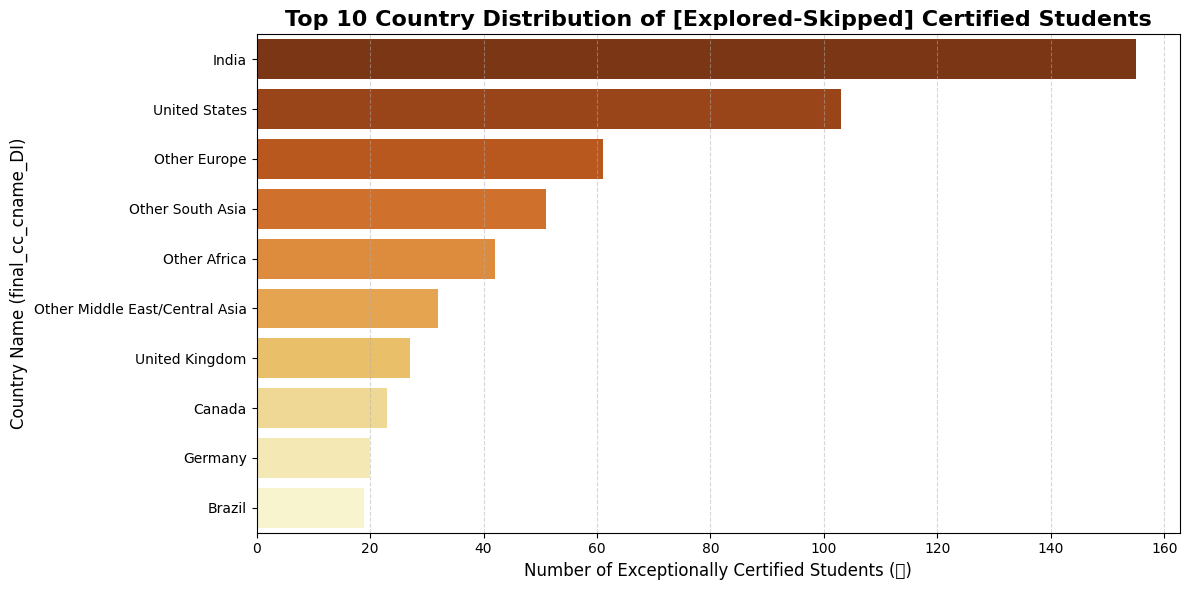

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 이전 코드에서 잡은 비정상 수료 집단(anomaly_cert_df)의 국가별(final_cc_cname_DI) 분포 세기
country_distribution = anomaly_cert_df['final_cc_cname_DI'].value_counts()

# 2. 결과 표 출력 (나라가 워낙 많으니 한눈에 보이게 텍스트로 먼저 봅니다)
print("👇 [탐방 스킵 수료자] 국가별 예외 수료 인원 분포표 👇")
display(country_distribution.to_frame(name="수료자 수(명)"))


# 3. 나라가 수십 개일 수 있으므로 상위 10개 국만 잘라서 가로 막대 그래프 그리기
if len(country_distribution) > 0:
    plt.figure(figsize=(12, 6))
    
    # 상위 10위까지만 잘라냅니다.
    top_10_countries = country_distribution.head(10)
    
    # 수치가 높을수록 짙은 주황~빨강 톤으로 경고색 매핑 (YlOrBr_r)
    sns.barplot(
        x=top_10_countries.values, 
        y=top_10_countries.index, 
        palette='YlOrBr_r' 
    )
    
    plt.title('Top 10 Country Distribution of [Explored-Skipped] Certified Students', fontsize=16, weight='bold')
    plt.xlabel('Number of Exceptionally Certified Students (명)', fontsize=12)
    plt.ylabel('Country Name (final_cc_cname_DI)', fontsize=12)
    
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.show()
else:
    print("해당 비정상 집단의 인원 자체가 0명이므로 그릴 국가 데이터가 없습니다!")


👇 [탐방 스킵 수료자] 집단의 성적(Grade) 기초 통계량 요약표 👇


,Grade 통계
count,690.000
mean,0.794
std,0.162
min,0.000
25%,0.650
50%,0.805
75%,0.950
max,1.000


-----------------------------------------------------------------
👇 [탐방 스킵 수료자] 들이 가장 흔하게 받은 점수 (상위 5묶음) 👇


,인원수(명)
grade,
1.00,86
0.99,34
0.97,23
0.61,20
0.62,19


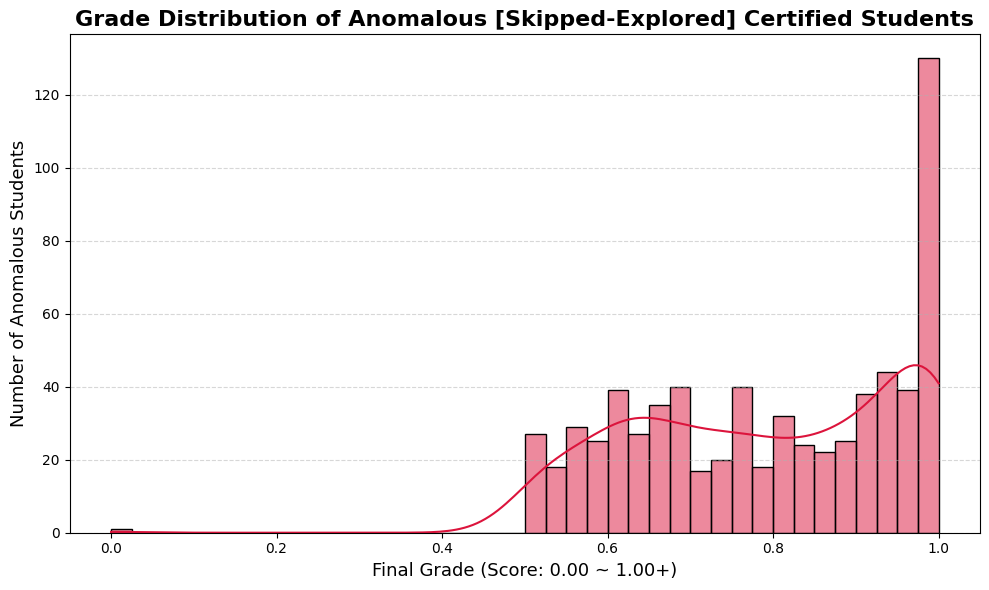

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# (만약을 대비한) 깔끔한 숫자(Float)형 강제 변환 
# (에러 무시 옵션을 달아놔서 기존에 정제하셨더라도 안전하게 돌아갑니다.)
anomaly_cert_df['grade'] = pd.to_numeric(anomaly_cert_df['grade'], errors='coerce')

# -------------------------------------------------------------
# 1. [통계표 분석] 꼼수 수료자들만의 성적(Grade) 뼈대 분석
# -------------------------------------------------------------
print("👇 [탐방 스킵 수료자] 집단의 성적(Grade) 기초 통계량 요약표 👇")
display(anomaly_cert_df['grade'].describe().round(3).to_frame(name="Grade 통계"))
print("-" * 65)

# 가장 징그럽게 많이 겹치는 빈도수 추출
print("👇 [탐방 스킵 수료자] 들이 가장 흔하게 받은 점수 (상위 5묶음) 👇")
display(anomaly_cert_df['grade'].value_counts().head(5).to_frame(name="인원수(명)"))


# -------------------------------------------------------------
# 2. [시각화 분석] 얌체 집단 성적 분포 (히스토그램)
# -------------------------------------------------------------
# 이 인원들이 1명이라도 존재할 경우에만 그래프를 그립니다.
if len(anomaly_cert_df) > 0:
    plt.figure(figsize=(10, 6))
    
    # 예외(비정상) 집단이므로 위험을 나타내는 붉은색(crimson)으로 칠해 보여줍니다.
    sns.histplot(anomaly_cert_df['grade'], bins=40, kde=True, color='crimson')
    
    plt.title('Grade Distribution of Anomalous [Skipped-Explored] Certified Students', fontsize=16, weight='bold')
    plt.xlabel('Final Grade (Score: 0.00 ~ 1.00+)', fontsize=13)
    plt.ylabel('Number of Anomalous Students', fontsize=13)
    
    # 가독성을 높이기 위해 배경 점선 긋기
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

else:
    print("이런 집단(탐방 없이 수료한 집단) 인원수가 0명이므로 그릴 점수도 없습니다!")
